# Genesis Potential Index (GPI) demo (EXPERIMENTAL)

This notebook demonstrates the `tcpyPI.genesis_potential_index()` utility with a transparent, step-by-step single-column example.

## Scientific basis / citations

This implementation provides two published GPI variants behind a switch:
- `en04`: [Emanuel & Nolan (2004)](https://www.researchgate.net/publication/255653517_Tropical_cyclone_activity_and_global_climate), using midlevel **relative humidity**
- `e10`: [Emanuel (2010, JAMES, Eq. 11](https://agupubs.onlinelibrary.wiley.com/doi/full/10.3894/JAMES.2010.2.1)), using the midlevel **moist-entropy deficit** `χ_m`

**As implemented in `tcpyPI.gpi`**, the two forms are:

- `en04`:

$$\mathrm{GPI} = (10^5|\eta|)^{3/2}\,(RH/50)^3\,(V_{PI}/70)^3\,(1+0.1\,V_{shear})^{-2}$$

- `e10`:

$$\mathrm{GPI} = |\eta|^{3}\,\chi_m^{-4/3}\,\max(V_{PI}-35,0)^{2}\,(25+V_{shear})^{-4}$$

Inputs:
- low-level absolute vorticity `|η|` (s⁻¹; commonly 850 hPa) — the sign is ignored (`|η|` is used)
- `en04`: midlevel relative humidity `RH` (%; commonly ~700 hPa); shear `Vshear` over 850–200 hPa
- `e10`: nondimensional midlevel (600 hPa) moist-entropy deficit `χ_m` ([Tang & Emanuel 2012](https://journals.ametsoc.org/view/journals/bams/93/12/bams-d-11-00165.1.xml), Eq. 2; from `tcpyPI.entropy_deficit_te12_from_profile`); shear `Vshear` over 850–250 hPa
- potential intensity `V_PI` (m/s; from `tcpyPI.pi`)

GPI is **unitless**. `en04` and `e10` magnitudes are best interpreted **relatively** (spatial/seasonal), not against each other.

## About the example environment

We use a single-column ERA5 **October 2024 monthly-mean** environment near **Hurricane Milton's (2024)** peak-intensity location, read from the tracked `data/era5_demo_subset.nc`.

**On the monthly mean:** a monthly mean is a *climatological* field and is perfectly appropriate for climatological GPI/PI analyses across many storms or seasons. It is *not* the pre-storm environment of this individual storm — to characterize the environment a specific storm developed in, you would use sub-monthly fields **3–5 days ahead** of passage (so the storm does not contaminate its own environment). Milton's location is used here purely as a concrete example. Expect GPI magnitudes to vary by orders of magnitude with the inputs; use them comparatively.

## 0) Setup

This repo uses a `src/` layout. This cell locates the repository root (by searching for `src/tcpyPI`) and adds `src/` to the import path so imports resolve without installation.

In [1]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
repo_root = None
for cand in [here] + list(here.parents):
    if (cand / "src" / "tcpyPI").is_dir():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError(
        "Could not locate repo root (expected src/tcpyPI). "
        "Run from within the repo or install with `pip install -e .`."
    )

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt

import tcpyPI
import tcpyPI.utilities as util

print("tcpyPI from:", tcpyPI.__file__)

tcpyPI from: /home/dgilford/tcpyPI/src/tcpyPI/__init__.py


## 1) ERA5 October 2024 profile, PI, and baseline inputs (Milton-region reference)

This section reads a single-column environment from the tracked demo subset (`data/era5_demo_subset.nc`), an ERA5 Oct-2024 monthly mean near Hurricane Milton's (2024) peak-intensity location. Units:
- `P` in hPa
- `TC` in °C
- `R` in g/kg (mixing ratio, `r = q/(1-q)`)
- `SSTC` in °C
- `MSL` in hPa

In [2]:
import xarray as xr

# Single-column ERA5 Oct-2024 monthly-mean environment near Hurricane Milton's
# (2024) peak-intensity location, built by data/build_sample_data_era5_oct2024.py
# and tracked in-repo, so this notebook runs on a fresh clone without the full ERA5
# download or IBTrACS.
DEMO_PATH = repo_root / "data" / "era5_demo_subset.nc"

ds = xr.open_dataset(DEMO_PATH)
milton_lat = ds.attrs["milton_lat"]
milton_lon_360 = ds.attrs["milton_lon"]
print("Reference:", ds.attrs["milton_time"], "| lat/lon (deg E):", milton_lat, milton_lon_360)

# Single column: pl_point and sl_point are the same dataset.
pl_point = ds.sortby("pressure_level", ascending=False)
sl_point = ds

P = pl_point["pressure_level"].values.astype(float)
TC = pl_point["t"].values.astype(float) - 273.15  # K -> C
q = pl_point["q"].values.astype(float)            # specific humidity, kg/kg
R = (q / (1.0 - q)) * 1000.0                       # mixing ratio, g/kg

SSTC = float(sl_point["sst"].values - 273.15)     # K -> C
MSL = float(sl_point["msl"].values / 100.0)       # Pa -> hPa

VMAX, PMIN, IFL, T0, OTL = tcpyPI.pi(SSTC, MSL, P, TC, R, CKCD=0.9)
print("PI status flag:", int(IFL))
print("V_PI (VMAX):", float(VMAX), "m/s")

Reference: 2024-10-07 20:00 UTC | lat/lon (deg E): 21.75 269.0
PI status flag: 1
V_PI (VMAX): 80.70671348974075 m/s


## 2) Midlevel RH (ERA5)

Many GPI variants use midlevel RH near 700 hPa. Here we read RH directly from the ERA5 pressure-level monthly-mean field at 700 hPa.

In [3]:
rh700 = float(pl_point["r"].sel(pressure_level=700.0, method="nearest").values)
print("RH(700 hPa):", rh700, "%")

RH(700 hPa): 52.57209777832031 %


## 3) Deep-layer shear and absolute vorticity (ERA5)

Compute these from ERA5 fields at the Milton reference grid point:
- `Vshear`: bulk 850–200 hPa shear magnitude (m/s)
- `|η|`: absolute vorticity magnitude at 850 hPa (s⁻¹), approximated as `|f + ζ|` where `ζ` is ERA5 relative vorticity (`vo`) and `f` is the Coriolis parameter.

|η| (850 hPa): 6.178759466839945e-05 s^-1
RH(700 hPa): 52.57209777832031 %
Vshear (850–200): 13.980576792534576 m/s


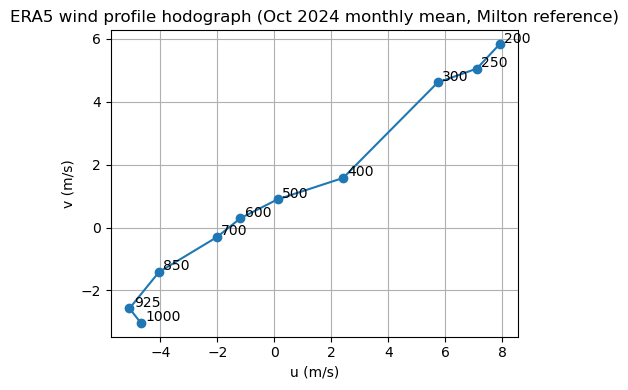

In [4]:
omega = 7.292115e-5  # rad/s
phi = np.deg2rad(milton_lat)
f = 2.0 * omega * np.sin(phi)
zeta850 = float(pl_point["vo"].sel(pressure_level=850.0, method="nearest").values)
abs_vort = float(np.abs(f + zeta850))

u850 = float(pl_point["u"].sel(pressure_level=850.0, method="nearest").values)
v850 = float(pl_point["v"].sel(pressure_level=850.0, method="nearest").values)
u200 = float(pl_point["u"].sel(pressure_level=200.0, method="nearest").values)
v200 = float(pl_point["v"].sel(pressure_level=200.0, method="nearest").values)
v_shear = float(np.hypot(u850 - u200, v850 - v200))

print('|η| (850 hPa):', abs_vort, 's^-1')
print('RH(700 hPa):', rh700, '%')
print('Vshear (850–200):', v_shear, 'm/s')

p_wind = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200], dtype=float)
u = pl_point["u"].sel(pressure_level=p_wind, method="nearest").values.astype(float)
v = pl_point["v"].sel(pressure_level=p_wind, method="nearest").values.astype(float)

plt.figure(figsize=(5, 4))
plt.plot(u, v, 'o-')
for pi, ui, vi in zip(p_wind, u, v):
    plt.text(ui + 0.15, vi + 0.05, f'{int(pi)}')
plt.xlabel('u (m/s)')
plt.ylabel('v (m/s)')
plt.title('ERA5 wind profile hodograph (Oct 2024 monthly mean, Milton reference)')
plt.grid(True)
plt.tight_layout()
plt.show()


## 4) Compute GPI

We evaluate the two supported variants:
- `en04`: Emanuel & Nolan (2004) / Camargo et al. (2007)-style (relative-humidity-based)
- `e10`: Emanuel (2010)-style (midlevel moist-entropy-deficit-based). We first compute `χ_m` at 600 hPa with the ventilation-index utility `tcpyPI.entropy_deficit_te12_from_profile`, then pass it to the GPI function.

In [5]:
# en04 uses midlevel RH; e10 uses the nondimensional midlevel entropy deficit chi_m
chi_m = tcpyPI.entropy_deficit_te12_from_profile(
    P, TC, R,
    T_units="C", q_units="g/kg",
    SST=SSTC, SST_units="C", psfc_hpa=MSL,
    T2m=TC[0], q2m=R[0],
    p_mid_hpa=600.0,
)

gpi_en04 = tcpyPI.genesis_potential_index(abs_vort, rh700, v_shear, float(VMAX), formulation="en04")
gpi_e10 = tcpyPI.genesis_potential_index(
    abs_vort, v_shear=v_shear, v_pot=float(VMAX), formulation="e10", chi=float(chi_m)
)

print("chi_m (600 hPa):", float(chi_m))
print("GPI (en04):", float(gpi_en04))
print("GPI (e10): ", float(gpi_e10))

chi_m (600 hPa): 0.38926707113063164
GPI (en04): 4.7579892788633495
GPI (e10):  7.509434876739269e-16


## 5) Simple sensitivity sketch

GPI is multiplicative, so it is often useful to visualize sensitivity by varying one factor at a time. Here we vary shear and humidity while holding everything else fixed to see how `en04` responds.

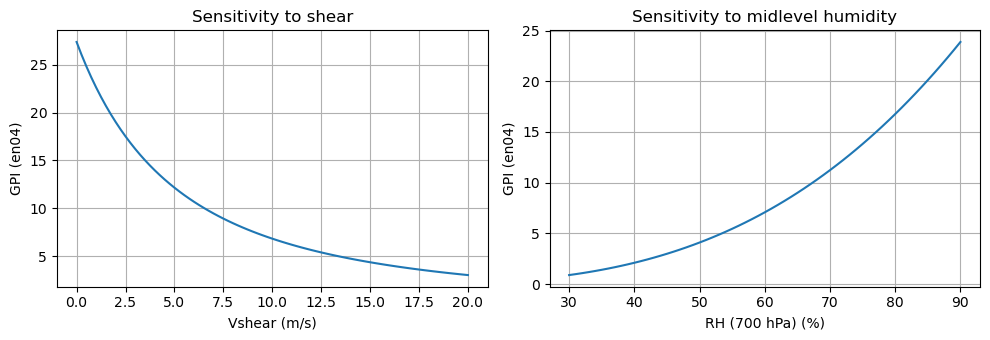

In [6]:
shears = np.linspace(0.0, 20.0, 81)
rhs = np.linspace(30.0, 90.0, 61)

gpi_vs_shear = np.array([tcpyPI.genesis_potential_index(abs_vort, rh700, vs, float(VMAX), formulation="en04") for vs in shears])
gpi_vs_rh = np.array([tcpyPI.genesis_potential_index(abs_vort, r, v_shear, float(VMAX), formulation="en04") for r in rhs])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(shears, gpi_vs_shear)
ax[0].set_xlabel("Vshear (m/s)")
ax[0].set_ylabel("GPI (en04)")
ax[0].set_title("Sensitivity to shear")
ax[0].grid(True)

ax[1].plot(rhs, gpi_vs_rh)
ax[1].set_xlabel("RH (700 hPa) (%)")
ax[1].set_ylabel("GPI (en04)")
ax[1].set_title("Sensitivity to midlevel humidity")
ax[1].grid(True)

plt.tight_layout()
plt.show()